## Open rates file

In [111]:
import pandas as pd
df_meta_cognates = pd.read_csv("final_phyloregression_results/metadata_heggarty2024.csv")
df_meta_speech = pd.read_csv("final_phyloregression_results/metadata_long_v3_CCD0.0.25.csv")

## Get Sound Inventory

In [107]:
import pandas as pd
# renaming mapping 
renaming_dict = {
    "Greek" : "Greek",
    "Armenian" : "ArmenianEastern",
    "French" : "French",
    "Catalan" : "Catalan",
    "Spanish" : "Spanish",
    "Portuguese" : "Portuguese",
    "Italian" : "Italian", 
    "Romanian" : "Romanian",
    "Danish" : "Danish",
    "Norwegian" : "NorwegianBokmal",
    "Swedish" : "Swedish",
    "Dutch" : "Dutch",
    "German" : "German",
    "English" : "English",
    "Belarusian" : "Belarusian",
    "Ukrainian" : "Ukrainian",
    "Russian" : "Russian",
    "Czech" : "Czech",
    "Slovak" : "Slovak",
    "Polish" : "Polish",
    "Bulgarian" : "Bulgarian",
    "Macedonian" : "Macedonian",
    "Serbian" : "SerboCroatian",
    "Slovene" : "Slovene",
    "Latvian" : "Latvian",
    "Lithuanian" : "Lithuanian",
    "Assamese" : "Assamese",
    "Bengali" : "Bengali",
    "Hindi" : "Hindi",
    "Urdu" : "Urdu",
    "Punjabi" : "Punjabi",
    "Nepali" : "Nepali",
    "Marathi" : "Marathi",
    "Persian" : "PersianTehran",
    "Kurdish" : "KurdishCJafi",
    "Pashto" : "Pashto",
}

# Download full dataset
phoible = pd.read_csv("https://raw.githubusercontent.com/phoible/dev/master/data/phoible.csv")

# only keep rows with languages in our mapping
phoible = phoible[phoible['LanguageName'].isin(renaming_dict.keys())]

# Filter to sources of interest
phoible_filtered = phoible[phoible['Source'].isin(["ea", "ra", "spa", "upsid"])].copy()

# Count phonemes per inventory
inventory_counts = phoible_filtered.groupby(
    ['LanguageName', 'Glottocode', 'Source', 'InventoryID']
).agg({'Phoneme': 'nunique'}).reset_index().rename(columns={'Phoneme': 'n_segments'})

# Priority: ea > ra > spa > upsid
source_priority = {'ea': 1, 'ra': 2, 'spa': 3, 'upsid': 4}
inventory_counts['priority'] = inventory_counts['Source'].map(source_priority)

# Pick best source per language
best_per_lang = inventory_counts.sort_values('priority').groupby('LanguageName').first().reset_index()
# rename languageName as language
best_per_lang = best_per_lang.rename(columns={'LanguageName': 'language'})

# Keep only languages in your mapping
result = best_per_lang[best_per_lang['language'].notna()][['language', 'Glottocode', 'Source', 'n_segments']]

# Check what's missing
target_languages = set(renaming_dict.keys())
found_languages = set(result['language'])
missing = target_languages - found_languages
print(f"Missing languages: {missing}")

# Handle Belarusian -> use Russian value
if 'Belarusian' in missing and 'Russian' in found_languages:
    russian_row = result[result['language'] == 'Russian'].iloc[0].copy()
    russian_row['language'] = 'Belarusian'
    russian_row['Source'] = 'proxy_from_Russian'
    result = pd.concat([result, pd.DataFrame([russian_row])], ignore_index=True)
    print("Added Belarusian using Russian as proxy")

# Sort and display
result = result.sort_values('language').reset_index(drop=True)
print(f"\nFound {len(result)} languages:")
print(result.to_string())

result['language'] = result['language'].map(renaming_dict)

# Save
# result.to_csv("inventory_sizes_phoible.csv", index=False)

Missing languages: {'Belarusian'}
Added Belarusian using Russian as proxy

Found 36 languages:
      language Glottocode              Source  n_segments
0     Armenian   nucl1235                 spa          37
1     Assamese   assa1263                  ea          36
2   Belarusian   russ1263  proxy_from_Russian          42
3      Bengali   beng1280                  ea          47
4    Bulgarian   bulg1262                  ea          43
5      Catalan   stan1289                  ea          34
6        Czech   czec1258                  ea          40
7       Danish   dani1285                  ea          26
8        Dutch   dutc1256                  ea          43
9      English   stan1293                  ea          44
10      French   stan1290                  ea          34
11      German   stan1295                  ea          40
12       Greek   mode1248                  ea          29
13       Hindi   hind1269                  ea          55
14     Italian   ital1282          

/home/people/habhuz/miniconda3/envs/speech_phylo/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3553: DtypeWarning: Columns (4,7,8,11) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [112]:
# merge with metadata to get family info
num_langs = df_meta_cognates.shape[0]
assert set(df_meta_cognates['language']) == set(result['language']), f"Language mismatch between metadata and inventory sizes! num_langs_meta={num_langs}, num_langs_inventory={result.shape[0]}, with diff={set(df_meta_cognates['language']) - set(result['language'])}"
df_meta_cognates = df_meta_cognates.merge(result[['language', 'n_segments']], on='language', how='inner')


assert set(df_meta_speech['language']) == set(result['language']), f"Language mismatch between metadata and inventory sizes! num_langs_meta={num_langs}, num_langs_inventory={result.shape[0]}, with diff={set(df_meta_speech['language']) - set(result['language'])}"
df_meta_speech = df_meta_speech.merge(result[['language', 'n_segments']], on='language', how='inner')

## Delta scores

In [115]:
delta_cognates = pd.read_csv("final_phyloregression_results/cognates_Heg_delta.txt", sep="\t")
delta_speech = pd.read_csv("final_phyloregression_results/speech_25pc_delta.txt", sep="\t")
delta_cognates.columns = ["id", "language", "delta", "Q-residual"]
delta_speech.columns = ["id", "language", "delta", "Q-residual"]

# merge with df_meta
df_meta_cognates = df_meta_cognates.merge(delta_cognates[['language', 'delta']], on='language', how='inner')
df_meta_speech = df_meta_speech.merge(delta_speech[['language', 'delta']], on='language', how='inner')

In [117]:
df_meta_speech.columns

Index(['language', 'node', 'CAheight_95%_HPD', 'CAheight_mean',
       'CAheight_median', 'CAheight_range', 'height', 'height_95%_HPD',
       'height_median', 'height_range', 'length', 'length_95%_HPD',
       'length_median', 'length_range', 'posterior', 'rate', 'rate_95%_HPD',
       'rate_median', 'rate_range', 'glottocode', 'n_speakers', 'latitude',
       'longitude', 'Hittite', 'log_speakers', 'taxonset', 'n_segments',
       'delta'],
      dtype='object')

In [118]:
# only keep columns ["language", "rate_median", "n_segments", "delta", "latitude", "longitude", "n_speakers"]
df_meta_cognates = df_meta_cognates[["language", "rate_median", "n_segments", "delta", "latitude", "longitude", "n_speakers"]]
df_meta_speech = df_meta_speech[["language", "rate_median", "n_segments", "delta", "latitude", "longitude", "n_speakers"]]

In [ ]:
df_meta_cognates.to_csv("final_phyloregression_results/metadata_heggarty2024_with_inventory_delta.csv", index=False)
df_meta_speech.to_csv("final_phyloregression_results/metadata_long_v3_CCD0.0.25_with_inventory_delta.csv", index=False)

In [122]:
df_meta_cognates

,language,rate_median,n_segments,delta,latitude,longitude,n_speakers
0,Greek,0.002051,29,0.30584,38.360000,23.130000,13.0
1,ArmenianEastern,0.001580,37,0.27560,40.000000,45.000000,6.0
2,French,0.003829,34,0.16870,48.000000,2.000000,280.0
3,Catalan,0.003681,34,0.17887,41.453000,1.569000,4.0
4,Spanish,0.001441,25,0.18173,40.441400,-1.117880,490.0
5,Portuguese,0.002810,41,0.16864,39.910000,-8.100000,220.0
6,Italian,0.002680,30,0.18105,43.046400,12.648900,61.0
7,Romanian,0.002088,51,0.16822,46.391300,24.225600,19.0
8,Danish,0.001388,26,0.18392,54.865500,9.362840,5.0
9,NorwegianBokmal,0.004962,40,0.18382,59.920000,10.710000,5.0


## Plotting

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path

VALID_COORD_METHODS = {"standard", "sqrt_plus_10", "log_plus_10"}

def load_all_results(dir, tree_names=["heggarty2024", "long_v3_CCD0.0.25"]):
    """Load all phylolm/lm and OAK results."""
    
    phylolm_bayesian_results = []
    oak_results = []
    
    # Load phylolm_bayesian results
    csv_files = []
    for tree_name in tree_names:
        csv_files += glob.glob(f"{dir}/phylolm_with_inventory_*{tree_name}*.csv")

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        filename = Path(csv_file).stem
        if "tree" not in df.columns:
            for tree_name in tree_names:
                if tree_name in filename:
                    df["tree"] = tree_name
                    break
        if "coordinate_method" not in df.columns:
            guess = filename.split("_")[-1]
            df["coordinate_method"] = guess if guess in VALID_COORD_METHODS else "standard"
        phylolm_bayesian_results.append(df)

    for phylolm_bayesian_df in phylolm_bayesian_results:
        if 'interaction' in phylolm_bayesian_df.columns:
            phylolm_bayesian_df.rename(columns={'interaction': 'interactionbool'}, inplace=True)

    # Load OAK Sobol indices
    for tree_name in tree_names:
        sobol_path = f"{dir}/oak_sobol_{tree_name}.csv"
        if Path(sobol_path).exists():
            df = pd.read_csv(sobol_path)
            df['tree'] = tree_name
            oak_results.append(df)

    # Combine dataframes
    phylolm_bayesian_df = pd.concat(phylolm_bayesian_results, ignore_index=True) if phylolm_bayesian_results else pd.DataFrame()
    oak_df = pd.concat(oak_results, ignore_index=True) if oak_results else pd.DataFrame()

    return phylolm_bayesian_df, oak_df


# Load the data
dir = "final_phyloregression_results"
phylolm_bayesian_df, oak_df = load_all_results(dir=dir)
# rename tree names for plotting
tree_name_map = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech (25%)"
}
phylolm_bayesian_df['tree'] = phylolm_bayesian_df['tree'].map(tree_name_map)
oak_df['tree'] = oak_df['tree'].map(tree_name_map)

In [16]:
phylolm_bayesian_df

,model,tree,coordinate_method,coef_Intercept,se_Intercept,ci_lower_Intercept,ci_upper_Intercept,coef_longitude,se_longitude,ci_lower_longitude,...,spline_partial_SS_mean,spline_partial_R2_mean,spline_partial_R2_q2_5,spline_partial_R2_q97_5,phylo_partial_SS_mean,phylo_partial_R2_mean,phylo_partial_R2_q2_5,phylo_partial_R2_q97_5,residual_SS_mean,n_obs
0,brms_phylo,Cognates,log_plus_10,-5.820788,0.230861,-6.270205,-5.330055,-0.198182,0.195657,-0.590821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,brms_phylo,Cognates,standard,-5.857907,0.099066,-6.061726,-5.665757,NaN,NaN,NaN,...,1.459811,0.275762,-0.023031,0.709026,0.473463,0.089438,-0.082647,0.580177,4.257166,36.0
2,brms_phylo,Cognates,sqrt_plus_10,-5.876059,0.232770,-6.309579,-5.381935,-0.167147,0.186384,-0.545790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,brms_phylo,Speech (25%),log_plus_10,2.032232,0.133139,1.765888,2.291741,-0.138202,0.093153,-0.327240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,brms_phylo,Speech (25%),sqrt_plus_10,2.017902,0.140073,1.739334,2.297270,-0.137208,0.105708,-0.347359,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,brms_phylo,Speech (25%),standard,1.918324,0.103171,1.711482,2.118426,NaN,NaN,NaN,...,0.874998,0.266201,0.031197,0.727387,3.270170,0.994884,0.627238,1.731740,0.105226,36.0


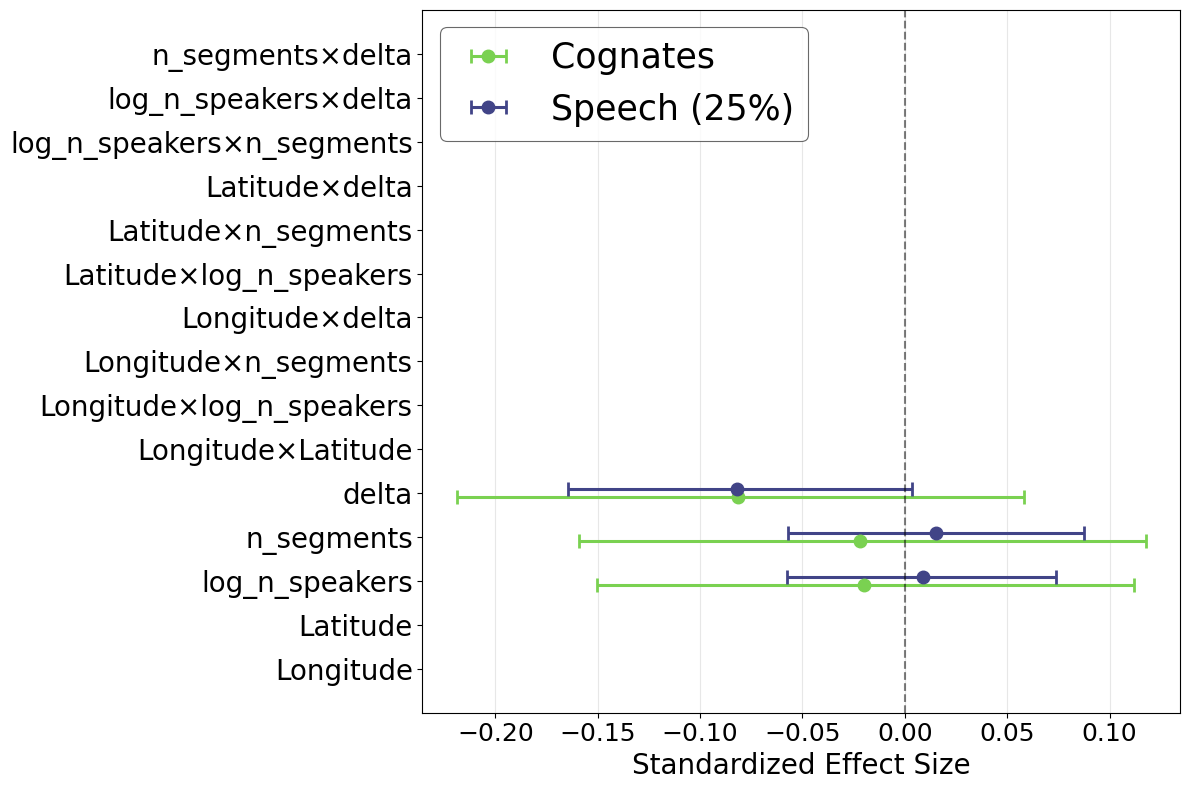

In [20]:
"""Visualization of Bayesian phylogenetic regression coefficients."""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional


# --- Configuration ---
COEFF_ORDER = [
    "Longitude",
    "Latitude",
    "log_n_speakers",
    "n_segments",
    "delta",
    "Longitude×Latitude",
    "Longitude×log_n_speakers",
    "Longitude×n_segments",
    "Longitude×delta",
    "Latitude×log_n_speakers",
    "Latitude×n_segments",
    "Latitude×delta",
    "log_n_speakers×n_segments",
    "log_n_speakers×delta",
    "n_segments×delta",
]

COEF_COLUMN_MAP = {
    "Longitude": ("coef_longitude", "ci_lower_longitude", "ci_upper_longitude"),
    "Latitude": ("coef_latitude", "ci_lower_latitude", "ci_upper_latitude"),
    "log_n_speakers": ("coef_log_n_speakers", "ci_lower_log_n_speakers", "ci_upper_log_n_speakers"),
    "n_segments": ("coef_n_segments", "ci_lower_n_segments", "ci_upper_n_segments"),
    "delta": ("coef_delta", "ci_lower_delta", "ci_upper_delta"),

    "Longitude×Latitude": ("coef_longitude_latitude", "ci_lower_longitude_latitude", "ci_upper_longitude_latitude"),
    "Longitude×log_n_speakers": ("coef_longitude_log_n_speakers", "ci_lower_longitude_log_n_speakers", "ci_upper_longitude_log_n_speakers"),
    "Longitude×n_segments": ("coef_longitude_n_segments", "ci_lower_longitude_n_segments", "ci_upper_longitude_n_segments"),
    "Longitude×delta": ("coef_longitude_delta", "ci_lower_longitude_delta", "ci_upper_longitude_delta"),

    "Latitude×log_n_speakers": ("coef_latitude_log_n_speakers", "ci_lower_latitude_log_n_speakers", "ci_upper_latitude_log_n_speakers"),
    "Latitude×n_segments": ("coef_latitude_n_segments", "ci_lower_latitude_n_segments", "ci_upper_latitude_n_segments"),
    "Latitude×delta": ("coef_latitude_delta", "ci_lower_latitude_delta", "ci_upper_latitude_delta"),

    "log_n_speakers×n_segments": ("coef_log_n_speakers_n_segments", "ci_lower_log_n_speakers_n_segments", "ci_upper_log_n_speakers_n_segments"),
    "log_n_speakers×delta": ("coef_log_n_speakers_delta", "ci_lower_log_n_speakers_delta", "ci_upper_log_n_speakers_delta"),
    "n_segments×delta": ("coef_n_segments_delta", "ci_lower_n_segments_delta", "ci_upper_n_segments_delta"),
}

PLOT_STYLE = {
    "figsize": (12, 8),
    "row_spacing": 4.0,
    "capsize": 5,
    "capthick": 2,
    "markersize": 9,
    "linewidth": 2.2,
    "ylabel_fontsize": 20,
    "xlabel_fontsize": 20,
    "tick_fontsize": 18,
    "legend_fontsize": 25,
}


def _ensure_dir(path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)


def _extract_coefficient_data(df: pd.DataFrame) -> pd.DataFrame:
    """Extract coefficient estimates and CIs from the raw results DataFrame."""
    rows = []
    for _, row in df.iterrows():
        tree = str(row["tree"])
        for display_name, (coef_col, ci_lower, ci_upper) in COEF_COLUMN_MAP.items():
            if not {coef_col, ci_lower, ci_upper}.issubset(df.columns):
                continue
            est, lower, upper = row.get(coef_col), row.get(ci_lower), row.get(ci_upper)
            if pd.notna(est) and pd.notna(lower) and pd.notna(upper):
                rows.append({
                    "coefficient": display_name,
                    "tree": tree,
                    "estimate": float(est),
                    "ci_lower": float(lower),
                    "ci_upper": float(upper),
                })
    return pd.DataFrame(rows)


def plot_bayesian_effects_comparison(
    phylolm_df: pd.DataFrame,
    output_path: str = "final_figuresv2/effects_comparison_bayesian_normalized.pdf",
    tree_colors = None,
) -> None:
    """
    Plot standardized effects with 95% credible intervals by coefficient and tree.
    
    Visualizes posterior coefficient estimates from Bayesian phylogenetic regression
    (e.g., brms with phylogenetic correlation structure) as a forest plot.
    
    Parameters
    ----------
    phylolm_df : pd.DataFrame
        Results DataFrame with columns: tree, coef_*, ci_lower_*, ci_upper_*
    output_path : str
        Path to save the figure (PDF)
    tree_colors : dict, optional
        Mapping from tree name to RGBA color tuple
    """
    if phylolm_df.empty:
        print("No Bayesian phylo results available.")
        return

    # Extract and deduplicate
    df = _extract_coefficient_data(phylolm_df)
    df = df.drop_duplicates(subset=["tree", "coefficient"])
    
    if df.empty:
        print("No coefficients matched the expected set.")
        return

    # Order coefficients
    df = df[df["coefficient"].isin(COEFF_ORDER)]
    df["coefficient"] = pd.Categorical(df["coefficient"], categories=COEFF_ORDER, ordered=True)
    df = df.sort_values(["coefficient", "tree"])

    # #7ad151 for cognates and #414487 for speech
    tree_colors = {
        "Cognates": "#7ad151",
        "Speech (25%)": "#414487"
    }
    trees = df["tree"].unique().tolist()

    # --- Plotting ---
    style = PLOT_STYLE
    fig, ax = plt.subplots(figsize=style["figsize"])
    
    y_base = np.arange(len(COEFF_ORDER)) * style["row_spacing"]
    offsets = np.linspace(-0.35, 0.35, len(trees)) if len(trees) > 1 else [0.0]

    for offset, tree in zip(offsets, trees):
        subset = df[df["tree"] == tree].set_index("coefficient").reindex(COEFF_ORDER)
        est = subset["estimate"].to_numpy(dtype=float)
        ci_lo = subset["ci_lower"].to_numpy(dtype=float)
        ci_hi = subset["ci_upper"].to_numpy(dtype=float)
        
        valid = ~np.isnan(est)
        if not valid.any():
            continue

        y_pos = y_base[valid] + offset
        ax.errorbar(
            est[valid], y_pos,
            xerr=[est[valid] - ci_lo[valid], ci_hi[valid] - est[valid]],
            fmt="o",
            color=tree_colors.get(tree, "gray"),
            capsize=style["capsize"],
            capthick=style["capthick"],
            markersize=style["markersize"],
            linewidth=style["linewidth"],
            label=tree,
        )

    # Styling
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_yticks(y_base)
    ax.set_yticklabels(COEFF_ORDER, fontsize=style["ylabel_fontsize"])
    ax.set_ylim(-style["row_spacing"], y_base[-1] + style["row_spacing"])
    ax.set_xlabel("Standardized Effect Size", fontsize=style["xlabel_fontsize"])
    ax.tick_params(axis="x", labelsize=style["tick_fontsize"])
    ax.grid(True, axis="x", alpha=0.3)
    
    legend = ax.legend(loc="best", fontsize=style["legend_fontsize"])
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_edgecolor("#444444")

    plt.tight_layout()
    _ensure_dir(output_path)
    # save SVG
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# --- Usage ---
if __name__ == "__main__":
    # Example: assumes phylolm_bayesian_df is already loaded
    plot_bayesian_effects_comparison(phylolm_bayesian_df[phylolm_bayesian_df['coordinate_method'] == "standard"], output_path="final_figuresv2/effects_comparison_with_inventory_standard.svg")

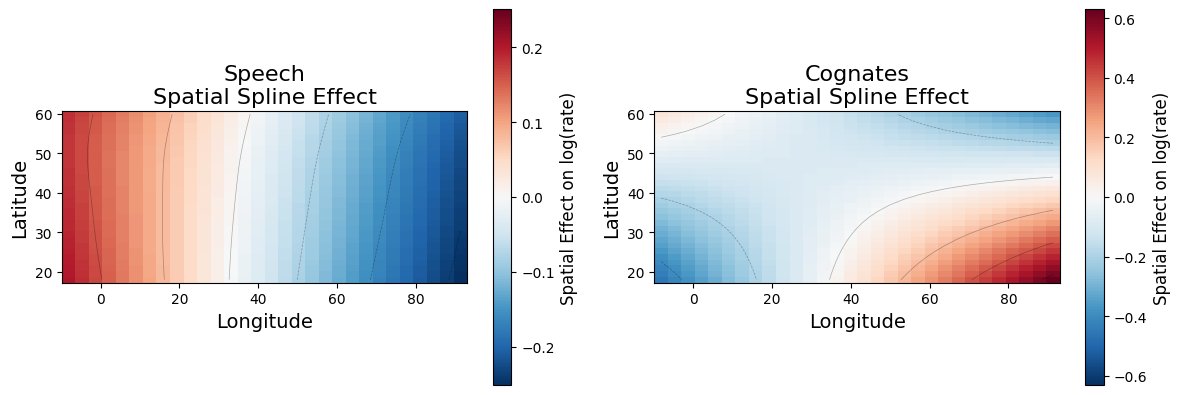

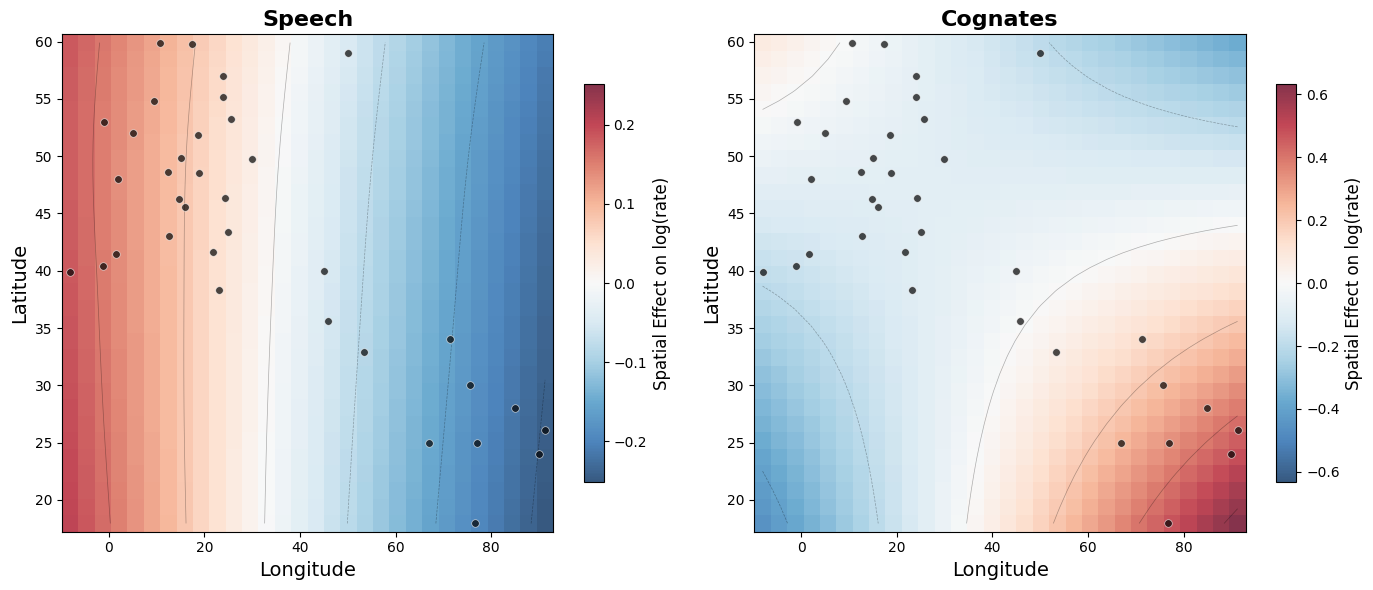

In [21]:
"""
Spline Surface Visualization
=============================
Plot the 2D spatial spline effect from Bayesian phylogenetic regression.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


def load_spline_surfaces(csv_dir: str, coord_method: str = "standard") -> dict:
    """
    Load spline surface predictions from CSV files.
    
    Returns dict mapping tree_name -> DataFrame with columns:
        longitude, latitude, spline_mean, spline_lower, spline_upper
    """
    pattern = os.path.join(csv_dir, f"spline_surface_*_{coord_method}.csv")
    csv_files = glob.glob(pattern)
    
    if not csv_files:
        print(f"No spline surface files found matching {pattern}")
        return {}
    
    surfaces = {}
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        # Extract tree name from filename
        basename = os.path.basename(csv_path)
        # Format: spline_surface_{tree_name}_{coord_method}.csv
        tree_name = basename.replace("spline_surface_", "").replace(f"_{coord_method}.csv", "")
        surfaces[tree_name] = df
    
    return surfaces


def plot_spline_surface(
    csv_dir: str = "speech_phylo/final_phyloregression_results",
    coord_method: str = "standard",
    tree_labels: dict = None,
    output_dir: str = "final_figuresv2",
    cmap: str = "RdBu_r",
) -> None:
    """
    Plot 2D spline surfaces showing spatial effects on log-rate.
    
    Creates one subplot per tree showing the spatial effect as a heatmap.
    """
    surfaces = load_spline_surfaces(csv_dir, coord_method)
    
    if not surfaces:
        print("No spline surfaces to plot.")
        return
    
    n_trees = len(surfaces)
    fig, axes = plt.subplots(1, n_trees, figsize=(6 * n_trees, 5))
    
    if n_trees == 1:
        axes = [axes]
    
    for ax, (tree_name, df) in zip(axes, surfaces.items()):
        # Get display name
        display_name = tree_labels.get(tree_name, tree_name) if tree_labels else tree_name
        
        # Pivot to grid
        lon_unique = np.sort(df['longitude'].unique())
        lat_unique = np.sort(df['latitude'].unique())
        
        # Create meshgrid for plotting
        lon_grid, lat_grid = np.meshgrid(lon_unique, lat_unique)
        
        # Pivot spline_mean to 2D array
        pivot = df.pivot(index='latitude', columns='longitude', values='spline_mean')
        spline_grid = pivot.values
        
        # Center colormap at 0
        vmax = np.abs(spline_grid).max()
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        # Plot heatmap
        im = ax.pcolormesh(
            lon_grid, lat_grid, spline_grid,
            cmap=cmap,
            norm=norm,
            shading='auto'
        )
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label("Spatial Effect on log(rate)", fontsize=12)
        
        # Labels
        ax.set_xlabel("Longitude", fontsize=14)
        ax.set_ylabel("Latitude", fontsize=14)
        ax.set_title(f"{display_name}\nSpatial Spline Effect", fontsize=16)
        ax.set_aspect('equal')
        
        # Add contour lines
        contours = ax.contour(
            lon_grid, lat_grid, spline_grid,
            levels=5,
            colors='black',
            alpha=0.3,
            linewidths=0.5
        )
    
    plt.tight_layout()
    
    os.makedirs(output_dir, exist_ok=True)
    svg_path = os.path.join(output_dir, f"spline_surface_{coord_method}.svg")
    # plt.savefig(svg_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_spline_surface_with_data(
    csv_dir: str = "speech_phylo/final_phyloregression_results",
    data_dir: str = "speech_phylo/final_phyloregression_results",
    coord_method: str = "standard",
    tree_labels: dict = None,
    output_dir: str = "final_figuresv2",
    cmap: str = "RdBu_r",
) -> None:
    """
    Plot spline surfaces with actual data points overlaid.
    """
    surfaces = load_spline_surfaces(csv_dir, coord_method)
    
    if not surfaces:
        print("No spline surfaces to plot.")
        return
    
    n_trees = len(surfaces)
    fig, axes = plt.subplots(1, n_trees, figsize=(7 * n_trees, 6))
    
    if n_trees == 1:
        axes = [axes]
    
    for ax, (tree_name, df) in zip(axes, surfaces.items()):
        display_name = tree_labels.get(tree_name, tree_name) if tree_labels else tree_name
        
        # Load original data if available
        data_path = os.path.join(data_dir, f"metadata_{tree_name}_with_inventory_delta.csv")
        data_df = None
        if os.path.exists(data_path):
            data_df = pd.read_csv(data_path)
        
        # Pivot to grid
        lon_unique = np.sort(df['longitude'].unique())
        lat_unique = np.sort(df['latitude'].unique())
        lon_grid, lat_grid = np.meshgrid(lon_unique, lat_unique)
        
        pivot = df.pivot(index='latitude', columns='longitude', values='spline_mean')
        spline_grid = pivot.values
        
        # Center colormap at 0
        vmax = np.abs(spline_grid).max()
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        # Plot heatmap
        im = ax.pcolormesh(
            lon_grid, lat_grid, spline_grid,
            cmap=cmap,
            norm=norm,
            shading='auto',
            alpha=0.8
        )
        
        # Overlay data points
        if data_df is not None and 'longitude' in data_df.columns:
            ax.scatter(
                data_df['longitude'], 
                data_df['latitude'],
                c='black',
                s=30,
                alpha=0.7,
                edgecolors='white',
                linewidths=0.5,
                zorder=10
            )
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label("Spatial Effect on log(rate)", fontsize=12)
        
        # Labels
        ax.set_xlabel("Longitude", fontsize=14)
        ax.set_ylabel("Latitude", fontsize=14)
        ax.set_title(f"{display_name}", fontsize=16, fontweight='bold')
        
        # Contours
        ax.contour(
            lon_grid, lat_grid, spline_grid,
            levels=5,
            colors='black',
            alpha=0.3,
            linewidths=0.5
        )
    
    plt.tight_layout()
    
    os.makedirs(output_dir, exist_ok=True)
    svg_path = os.path.join(output_dir, f"spline_surface_with_inventory_data_{coord_method}.svg")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":
    tree_labels = {
        "long_v3_CCD0.0.25": "Speech",
        "heggarty2024": "Cognates",
    }
    
    # Basic surface plot
    plot_spline_surface(
        csv_dir="final_phyloregression_results",
        coord_method="standard",
        tree_labels=tree_labels,
    )
    
    # Surface with data points overlaid
    plot_spline_surface_with_data(
        csv_dir="final_phyloregression_results",
        data_dir="final_phyloregression_results",
        coord_method="standard",
        tree_labels=tree_labels,
    )



Proportional Variance Decomposition (standard)

Cognates:
  log_n_speakers      :   2.2% (0%–10%)
  n_segments          :   2.2% (0%–10%)
  delta               :   5.0% (0%–18%)
  Spatial (spline)    :  20.5% (0%–41%)
  Phylogenetic        :   6.7% (0%–37%)
  Residual            :  63.4% (38%–86%)
  Total               : 100.0%

Speech:
  log_n_speakers      :   1.0% (0%–5%)
  n_segments          :   1.7% (0%–7%)
  delta               :   6.3% (0%–17%)
  Spatial (spline)    :  18.1% (2%–40%)
  Phylogenetic        :  70.4% (45%–92%)
  Residual            :   2.4% (0%–13%)
  Total               : 100.0%


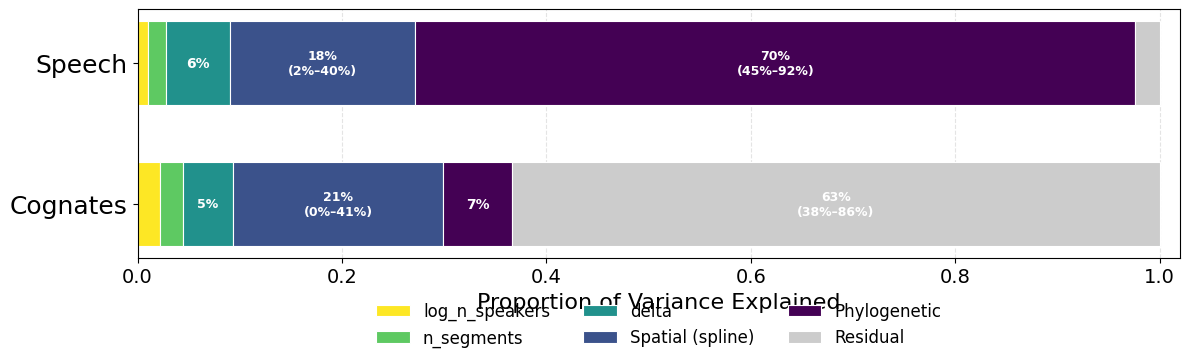

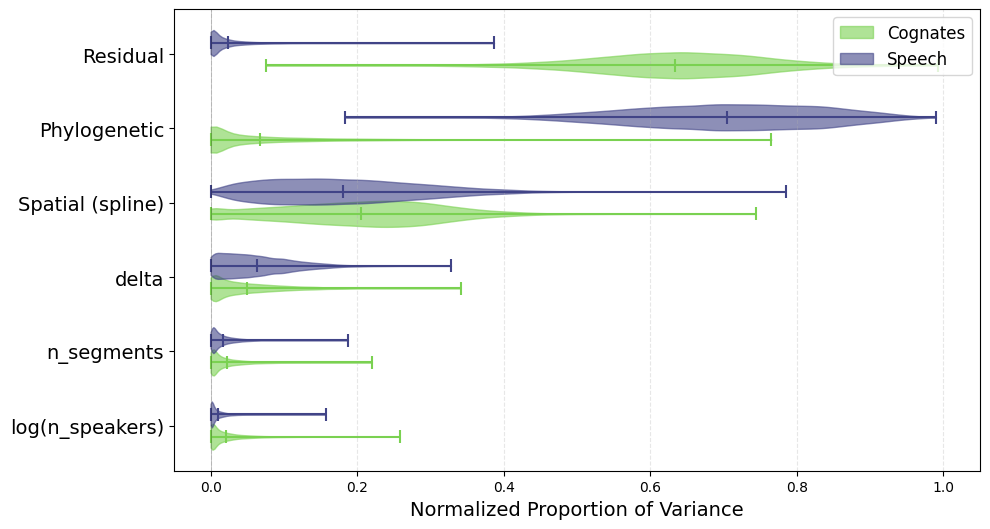

In [22]:
"""
Updated Variance Decomposition Plotting Code
=============================================
Copy this code into the appropriate cells in:
  speech_phylo/phyloregression_other_variables.ipynb

This code works with the new ANOVA-style variance decomposition output.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simplified order for the current model (no interactions)
VARIANCE_COMPONENT_ORDER = [
    "log_n_speakers",
    "n_segments",
    "delta",
    "Spatial (spline)",
    "Phylogenetic",
    "Residual",
]

# Viridis-inspired colors
VARIANCE_COLORS = {
    "log_n_speakers": "#fde725",
    "n_segments": "#5ec962",
    "delta": "#21918c",
    "Spatial (spline)": "#3b528b",
    "Phylogenetic": "#440154",
    "Residual": "#cccccc",
}

# Map CSV columns to display names (for per-term Shapley values)
CSV_TO_DISPLAY = {
    "partial_R2_log_n_speakers_norm": "log_n_speakers",
    "partial_R2_n_segments_norm": "n_segments",
    "partial_R2_delta_norm": "delta",
}


def load_phylo_variance_results(csv_dir: str, coord_method: str = "standard") -> pd.DataFrame:
    """
    Load ANOVA-style variance decomposition from phylogenetic regression CSVs.
    Returns partial R² with 95% CI for each variance component.
    """
    pattern = os.path.join(csv_dir, f"phylolm_with_inventory_*_{coord_method}.csv")
    csv_files = glob.glob(pattern)

    if not csv_files:
        print(f"No CSV files found matching {pattern}")
        return pd.DataFrame()
    
    records = []
    
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        tree_name = df["tree"].iloc[0]
        
        # Per-term Shapley contributions (linear effects only)
        for csv_col, display_name in CSV_TO_DISPLAY.items():
            if csv_col in df.columns:
                prop_mean = df[csv_col].iloc[0]
                q2_5_col = f"{csv_col}_q2_5"
                q97_5_col = f"{csv_col}_q97_5"
                prop_q2_5 = df[q2_5_col].iloc[0] if q2_5_col in df.columns else np.nan
                prop_q97_5 = df[q97_5_col].iloc[0] if q97_5_col in df.columns else np.nan
                
                records.append({
                    "tree": tree_name,
                    "component": display_name,
                    "variance_prop": prop_mean,
                    "prop_q2_5": prop_q2_5,
                    "prop_q97_5": prop_q97_5,
                })
        
        # Spatial spline component (Type III partial R²)
        if "spline_partial_R2_mean" in df.columns:
            records.append({
                "tree": tree_name,
                "component": "Spatial (spline)",
                "variance_prop": df["spline_partial_R2_mean"].iloc[0],
                "prop_q2_5": df["spline_partial_R2_q2_5"].iloc[0],
                "prop_q97_5": df["spline_partial_R2_q97_5"].iloc[0],
            })
        
        # Phylogenetic proportion (Type III partial R²)
        if "phylo_partial_R2_mean" in df.columns:
            records.append({
                "tree": tree_name,
                "component": "Phylogenetic",
                "variance_prop": df["phylo_partial_R2_mean"].iloc[0],
                "prop_q2_5": df["phylo_partial_R2_q2_5"].iloc[0],
                "prop_q97_5": df["phylo_partial_R2_q97_5"].iloc[0],
            })
        
        # Residual proportion
        if "residual_prop_mean" in df.columns:
            records.append({
                "tree": tree_name,
                "component": "Residual",
                "variance_prop": df["residual_prop_mean"].iloc[0],
                "prop_q2_5": df["residual_prop_q2_5"].iloc[0],
                "prop_q97_5": df["residual_prop_q97_5"].iloc[0],
            })
    
    return pd.DataFrame(records)


def plot_phylo_variance_stacked(
    csv_dir: str = "speech_phylo/final_phyloregression_results",
    coord_method: str = "standard",
    tree_order: list = None,
    tree_labels: dict = None,
    output_dir: str = "final_figuresv2",
    file_stub: str = "phyloLM_variance_stacked",
    normalize: bool = True,
    show_individual_linear: bool = True,  # Show individual Shapley terms
) -> None:
    """Plot ANOVA-style variance decomposition as stacked horizontal bars per tree."""
    
    # Try to load posterior samples for proper normalized CIs
    samples = load_variance_samples(csv_dir, coord_method)
    
    if samples.empty:
        print("No samples found. Run R script first.")
        return
    
    # Determine which columns to use
    if show_individual_linear:
        # Use individual Shapley terms + other components
        col_map = {
            'shapley_norm_log_n_speakers': 'log_n_speakers',
            'shapley_norm_n_segments': 'n_segments',
            'shapley_norm_delta': 'delta',
            'prop_spline_norm': 'Spatial (spline)',
            'prop_phylo_norm': 'Phylogenetic',
            'prop_residual_norm': 'Residual',
        }
        component_order = ['log_n_speakers', 'n_segments', 'delta', 'Spatial (spline)', 'Phylogenetic', 'Residual']
    else:
        col_map = {
            'prop_linear_norm': 'Linear Effects',
            'prop_spline_norm': 'Spatial (spline)',
            'prop_phylo_norm': 'Phylogenetic',
            'prop_residual_norm': 'Residual',
        }
        component_order = ['Linear Effects', 'Spatial (spline)', 'Phylogenetic', 'Residual']
    
    # Apply tree labels
    if tree_labels:
        samples['tree_display'] = samples['tree'].map(tree_labels).fillna(samples['tree'])
    else:
        samples['tree_display'] = samples['tree']
    
    trees = samples['tree_display'].unique()
    
    # Compute summary statistics from normalized samples
    summary_data = {}
    for tree_display in trees:
        tree_samples = samples[samples['tree_display'] == tree_display]
        summary_data[tree_display] = {}
        for col, comp_name in col_map.items():
            if col in tree_samples.columns:
                vals = tree_samples[col].dropna().values
                summary_data[tree_display][comp_name] = {
                    'mean': np.mean(vals),
                    'q2_5': np.percentile(vals, 2.5),
                    'q97_5': np.percentile(vals, 97.5),
                }
            else:
                summary_data[tree_display][comp_name] = {'mean': 0, 'q2_5': 0, 'q97_5': 0}
    
    # Build summary DataFrames
    summary = pd.DataFrame({
        tree: {comp: summary_data[tree][comp]['mean'] for comp in component_order}
        for tree in trees
    }).T
    summary = summary[component_order]
    
    summary_q2_5 = pd.DataFrame({
        tree: {comp: summary_data[tree][comp]['q2_5'] for comp in component_order}
        for tree in trees
    }).T
    summary_q2_5 = summary_q2_5[component_order]
    
    summary_q97_5 = pd.DataFrame({
        tree: {comp: summary_data[tree][comp]['q97_5'] for comp in component_order}
        for tree in trees
    }).T
    summary_q97_5 = summary_q97_5[component_order]
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"Proportional Variance Decomposition ({coord_method})")
    print(f"{'='*60}")
    for tree_display in summary.index:
        print(f"\n{tree_display}:")
        total = 0
        for comp in component_order:
            mean = summary.loc[tree_display, comp]
            q2_5 = summary_q2_5.loc[tree_display, comp]
            q97_5 = summary_q97_5.loc[tree_display, comp]
            total += mean
            if abs(mean) > 0.001:
                print(f"  {comp:20s}: {mean:6.1%} ({q2_5:.0%}–{q97_5:.0%})")
        print(f"  {'Total':20s}: {total:6.1%}")
    
    # ─── Plot ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, max(3.8, 1.35 * len(summary.index))))
    
    y_positions = np.arange(len(summary.index))
    left = np.zeros(len(summary.index))
    
    # Colors
    colors = {
        'log_n_speakers': '#fde725',
        'n_segments': '#5ec962',
        'delta': '#21918c',
        'Linear Effects': '#21918c',
        'Spatial (spline)': '#3b528b',
        'Phylogenetic': '#440154',
        'Residual': '#cccccc',
    }
    
    for comp in component_order:
        values = summary[comp].to_numpy(dtype=float)
        q2_5_vals = summary_q2_5[comp].to_numpy(dtype=float)
        q97_5_vals = summary_q97_5[comp].to_numpy(dtype=float)
        
        if np.allclose(values, 0.0):
            continue
        
        bars = ax.barh(
            y_positions,
            values,
            left=left,
            height=0.6,
            color=colors.get(comp, "#999999"),
            edgecolor="white",
            linewidth=0.8,
            label=comp,
        )
        
        # Add value labels WITH uncertainty in brackets
        for i, bar in enumerate(bars):
            width = bar.get_width()
            if width < 0.03:
                continue
            
            mean_pct = values[i]
            q2_5_pct = q2_5_vals[i]
            q97_5_pct = q97_5_vals[i]
            
            # Format label with uncertainty (now bounded 0-100%)
            if width >= 0.12:
                label = f"{mean_pct:.0%}\n({q2_5_pct:.0%}–{q97_5_pct:.0%})"
                fontsize = 9
            elif width >= 0.06:
                label = f"{mean_pct:.0%}"
                fontsize = 10
            else:
                label = f"{mean_pct:.0%}"
                fontsize = 9
            
            ax.text(
                bar.get_x() + width / 2.0,
                bar.get_y() + bar.get_height() / 2.0,
                label,
                ha="center",
                va="center",
                fontsize=fontsize,
                color="white",
                fontweight="bold",
                clip_on=False,
            )
        left += values
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(summary.index, fontsize=18)
    ax.set_xlabel("Proportion of Variance Explained", fontsize=16)
    ax.set_xlim(0, 1.02)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(axis="x", linestyle="--", color="#bcbcbc", alpha=0.4)
    ax.set_axisbelow(True)
    
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=12
    )
    
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    file_stub = f"{file_stub}_{coord_method}"
    svg_path = os.path.join(output_dir, f"{file_stub}.svg")
    # plt.savefig(svg_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================================
# VIOLIN PLOT FOR FULL POSTERIOR DISTRIBUTION
# ============================================================================

def load_variance_samples(csv_dir: str, coord_method: str = "standard") -> pd.DataFrame:
    """Load posterior samples of variance components for violin plots."""
    pattern = os.path.join(csv_dir, f"variance_samples_*_{coord_method}.csv")
    csv_files = glob.glob(pattern)
    
    if not csv_files:
        print(f"No variance samples found matching {pattern}")
        print("Run the R script first to generate posterior samples.")
        return pd.DataFrame()
    
    dfs = []
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)


def plot_variance_violin(
    csv_dir: str = "speech_phylo/final_phyloregression_results",
    coord_method: str = "standard",
    tree_labels: dict = None,
    output_dir: str = "final_figuresv2",
    use_normalized: bool = True,
    show_individual_linear: bool = True,
) -> None:
    """
    Plot overlapping violin plots for all trees on a single plot.
    Uses transparency to show both Cognates and Speech distributions.
    """
    samples = load_variance_samples(csv_dir, coord_method)
    
    if samples.empty:
        return
    
    # Map tree names
    if tree_labels:
        samples['tree_display'] = samples['tree'].map(tree_labels).fillna(samples['tree'])
    else:
        samples['tree_display'] = samples['tree']
    
    # Tree-specific colors with transparency
    tree_colors = {
        'Cognates': '#7ad151',
        'Speech': '#414487',
    }
    
    # Select columns based on options
    if show_individual_linear:
        if use_normalized:
            col_map = {
                'shapley_norm_log_n_speakers': 'log(n_speakers)',
                'shapley_norm_n_segments': 'n_segments',
                'shapley_norm_delta': 'delta',
                'prop_spline_norm': 'Spatial (spline)',
                'prop_phylo_norm': 'Phylogenetic',
                'prop_residual_norm': 'Residual',
            }
        else:
            col_map = {
                'shapley_log_n_speakers': 'log(n_speakers)',
                'shapley_n_segments': 'n_segments',
                'shapley_delta': 'delta',
                'partial_R2_spline': 'Spatial (spline)',
                'partial_R2_phylo': 'Phylogenetic',
                'prop_residual': 'Residual',
            }
        comp_order = ['log(n_speakers)', 'n_segments', 'delta', 'Spatial (spline)', 'Phylogenetic', 'Residual']
    else:
        if use_normalized:
            col_map = {
                'prop_linear_norm': 'Linear Effects',
                'prop_spline_norm': 'Spatial (spline)',
                'prop_phylo_norm': 'Phylogenetic',
                'prop_residual_norm': 'Residual',
            }
        else:
            col_map = {
                'partial_R2_linear': 'Linear Effects',
                'partial_R2_spline': 'Spatial (spline)',
                'partial_R2_phylo': 'Phylogenetic',
                'prop_residual': 'Residual',
            }
        comp_order = ['Linear Effects', 'Spatial (spline)', 'Phylogenetic', 'Residual']
    
    xlabel = "Normalized Proportion of Variance" if use_normalized else "Partial R² (Type III)"
    
    # Get unique trees
    trees = samples['tree_display'].unique()
    
    # Create single figure
    n_comps = len(comp_order)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.9 * n_comps)))
    
    # Offset for overlapping violins
    offset = 0.15
    
    for t_idx, tree_display in enumerate(trees):
        tree_data = samples[samples['tree_display'] == tree_display]
        color = tree_colors.get(tree_display, '#888888')
        
        # Get data for each component
        violin_data = []
        for c in comp_order:
            col_name = [k for k, v in col_map.items() if v == c]
            if col_name and col_name[0] in tree_data.columns:
                vals = tree_data[col_name[0]].dropna().values
                violin_data.append(vals if len(vals) > 0 else np.array([0]))
            else:
                violin_data.append(np.array([0]))
        
        # Position offset for this tree
        positions = np.arange(n_comps) + (t_idx - 0.5) * offset * 2
        
        # Create violin plot
        parts = ax.violinplot(
            violin_data,
            positions=positions,
            vert=False,
            showmeans=True,
            showmedians=False,
            widths=0.35,
        )
        
        # Color the violins with transparency
        for body in parts['bodies']:
            body.set_facecolor(color)
            body.set_alpha(0.6)
            body.set_edgecolor(color)
            body.set_linewidth(1)
        
        # Style the lines
        for partname in ['cmeans', 'cmins', 'cmaxes', 'cbars']:
            if partname in parts:
                parts[partname].set_edgecolor(color)
                parts[partname].set_linewidth(1.5)
    
    # Labels and styling
    ax.set_yticks(range(n_comps))
    ax.set_yticklabels(comp_order, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    if use_normalized:
        ax.set_xlim(-0.05, 1.05)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=tree_colors.get(t, '#888888'), alpha=0.6, 
                             edgecolor=tree_colors.get(t, '#888888'), label=t) 
                       for t in trees]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    svg_path = os.path.join(output_dir, f"variance_violin_overlay_with_inventory_{coord_method}.svg")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================================
# USAGE - Copy this cell to run the plots
# ============================================================================
if __name__ == "__main__":
    tree_labels = {
        "long_v3_CCD0.0.25": "Speech",
        "heggarty2024": "Cognates",
    }
    
    # Stacked bar plot
    plot_phylo_variance_stacked(
        csv_dir="final_phyloregression_results",
        coord_method="standard",
        tree_labels=tree_labels,
    )
    
    # Violin plot (requires running R script first to generate samples)
    plot_variance_violin(
        csv_dir="final_phyloregression_results",
        coord_method="standard",
        tree_labels=tree_labels,
        use_normalized=True,
    )
